In [1]:
from utils import (
    load_session_dumps,
    load_recal_dumps,
    build_session_summary,
    preprocess_dumps,
    flag_outlier_dumps,
    vlsr_correction,
    build_overlap_grid,
    build_lsr_pairs,
    build_recal_visits,
    aggregate_recal_visits,
    flag_outlier_pairs,
    combine_viable_pairs,
    compute_cell_metrics,
    neighbor_qa,
    collect_reobserve,
    assemble_W_R_arrays,
)
from plotters import (
    plot_spectra_grid,
    plot_survey_mollweide,
    plot_survey_mollweide_gridded,
    spectra_per_session_pdf,
)
from ugradiolab import plotting
from ugradiolab.plotting import SS_MICRO, SS_FINE

from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

# --- Hardware / signal-processing constants ---
SAMPLE_RATE_HZ = 3.2e6
NFFT = 1024
F1_MHZ = 1419.86
F2_MHZ = 1421.14
HPBW_DEG = 3.4
# NBLOCKS * NSAMPLES / fs (post-rewrite main pipeline)
INT_TIME_S = 1025 * 16384 / SAMPLE_RATE_HZ  # ~5.25 s

# --- RFI channel flagger (applied to both pols) ---
RFI_WINDOW = 15
RFI_SIGMA = 10.0
RFI_CHEB_DEGREE = 3
RFI_SAMPLE_FRAC = 0.7
RFI_EXTREMA_ORDER = 2

# --- Outlier dump filter ---
SHAPE_DEV_THRESH = 0.05
SHAPE_FRAC_THRESH = 0.05
SHAPE_MIN_GROUP_SIZE = 3

# --- Frequency switching ---
EDGE_TRIM_MHZ = 0.256

# --- Recal visit clustering ---
RECAL_VISIT_GAP_SEC = 300.0  # > 5 min separates visits; <<= inter-visit gap

# --- Cross-session pair filter (on dimensionless R) ---
PAIR_NSIGMA = 5.0
PAIR_FRAC_THRESH = 0.15
MIN_VIABLE_PAIRS = 3
PAIR_SPECTRUM_KEY = 'R_lsr'

# --- Per-cell metrics ---
METRIC_MIN_VALID_CH = 8
METRIC_NOISE_V_MAX_KMS = -100.0
METRIC_SIGNAL_V_LO_KMS = -80.0
METRIC_SIGNAL_V_HI_KMS = 60.0
METRIC_SMOOTH_KERNEL = 5
METRIC_PEAK_MIN_SEP_KMS = 4.0
METRIC_PEAK_PROM_NSIGMA = 2.5
METRIC_MIN_NOISE_CH = 5

# --- Neighbor QA (operates on R; W is in km/s) ---
NEIGHBOR_MAX_SEP_DEG = 2.1
MIN_NEIGHBORS = 2
W_Z_THRESH = 3.0
W_FRAC_THRESH = 0.30
W_SCALE_FLOOR = 5.0
PEAK_V_Z_THRESH = 3.0
PEAK_V_ABS_THRESH = 15.0
PEAK_V_MIN_SIGMA = 3.0
PEAK_V_SCALE_FLOOR = 20.0
BIMODAL_MIN_RATIO = 0.68

# --- Paths / display ---
DATA_DIRS = [Path('data/main'), Path('data/nps')]
REOBSERVE_PATH = Path('artifacts/main_reobserve.json')
SPECTRA_PDF_PATH = Path('artifacts/spectra_per_session.pdf')
STATE_PATH = Path('artifacts/scan_load_state.pkl')
MOLL_CENTER_L = 120.0

get_ipython().run_line_magic('matplotlib', 'inline')

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load raw dumps (science + recal)

Science cells feed the survey pipeline; recal-pointing visits are loaded
into a parallel structure so they stay out of `cell_combined` and remain
available later for pol-0 cross-calibration or T_cal-drift work.


In [2]:
records = load_session_dumps(DATA_DIRS, skip_recal=True)
recal_records = load_recal_dumps(DATA_DIRS)
sessions = sorted({r['session'] for r in records})

display(build_session_summary(records, INT_TIME_S))

n_sci = sum(1 for r in records if not r['noise_on'])
n_cal = sum(1 for r in records if r['noise_on'])
lo_unique = sorted({r['lo_mhz'] for r in records if not r['noise_on']})
print(f'Science: {len(records)} dumps ({n_sci} obs, {n_cal} cal), '
      f'{len(sessions)} sessions, LO: {lo_unique}')

recal_targets = sorted({r['target_id'] for r in recal_records})
recal_sessions = sorted({r['session'] for r in recal_records})
print(f'Recal:   {len(recal_records)} dumps across '
      f'{len(recal_sessions)} sessions; targets: {recal_targets}')


,Session,UTC Start,UTC End,Wall (min),Obs. Cells,Dumps,Duty %
0,main/session_001,2026-05-14 01:56,2026-05-14 02:40,44.0,24,288,57.3
1,main/session_002,2026-05-14 07:34,2026-05-14 09:35,121.0,63,756,54.7
2,main/session_003,2026-05-14 09:41,2026-05-14 12:14,153.3,82,984,56.1
3,main/session_004,2026-05-14 12:32,2026-05-14 15:16,163.3,83,996,53.4
4,main/session_005,2026-05-14 15:23,2026-05-14 17:56,153.8,79,948,53.9
5,main/session_006,2026-05-14 18:05,2026-05-14 20:00,114.9,54,645,49.1
6,nps/session_001,2026-05-14 02:59,2026-05-14 06:25,206.6,110,1320,55.9


Science: 5937 dumps (3957 obs, 1980 cal), 7 sessions, LO: [1419.86, 1421.14]
Recal:   756 dumps across 7 sessions; targets: ['recal_drift', 'recal_drift_bk']


## 2. fftshift + RFI flagging + outlier dump filter

Per-pol RFI is flagged on both `corr00` and `corr11` independently, then
the science alias `stokes_I = corr00 + corr11` is set on each record.
HI is unpolarised, so summing the two linear-feed auto-correlations
yields true Stokes I with ~sqrt(2) SNR gain over a single pol. Channels
NaN in either pol propagate to NaN in the sum (a half-flagged channel
would be biased low, so this is the right behaviour). Both science and
recal records are preprocessed with identical settings.

The cal-side concern about pol 0 at 3.2 MHz (T_cal coupling) is a
calibration accuracy issue and does not affect the dimensionless ratio
R, which this notebook produces -- so both pols feed the canonical R.

In [3]:
def _preprocess(records, label):
    n = preprocess_dumps(
        records,
        rfi_window=RFI_WINDOW,
        rfi_sigma=RFI_SIGMA,
        rfi_degree=RFI_CHEB_DEGREE,
        rfi_sample_frac=RFI_SAMPLE_FRAC,
        rfi_extrema_order=RFI_EXTREMA_ORDER,
    )
    print(f'{label}: RFI flagged {n} channel samples '
          f'across {len(records)} dumps (both pols)')


_preprocess(records, 'Science')
_preprocess(recal_records, 'Recal  ')

sci_out = flag_outlier_dumps(
    records,
    dev_thresh=SHAPE_DEV_THRESH,
    frac_thresh=SHAPE_FRAC_THRESH,
    min_group_size=SHAPE_MIN_GROUP_SIZE,
)
rec_out = flag_outlier_dumps(
    recal_records,
    dev_thresh=SHAPE_DEV_THRESH,
    frac_thresh=SHAPE_FRAC_THRESH,
    min_group_size=SHAPE_MIN_GROUP_SIZE,
)
print(f'Outlier dump filter: removed {len(sci_out)} science, {len(rec_out)} recal '
      f'(>{SHAPE_FRAC_THRESH:.0%} channels deviate >{SHAPE_DEV_THRESH:.0%} from group median)')
print(f'Remaining: {len(records)} science, {len(recal_records)} recal dumps')

Science: RFI flagged 45551 channel samples across 5937 dumps (both pols)
Recal  : RFI flagged 5334 channel samples across 756 dumps (both pols)
Outlier dump filter: removed 0 science, 0 recal (>5% channels deviate >5% from group median)
Remaining: 5937 science, 756 recal dumps


## 3. Frequency switching (R)

Pair dumps at f1 and f2, compute R = (I_f1 - I_f2) / I_f2.


In [4]:
grid = build_overlap_grid(
    F1_MHZ, F2_MHZ, SAMPLE_RATE_HZ, NFFT,
    edge_trim_mhz=EDGE_TRIM_MHZ,
)
overlap_mask = grid['overlap_mask']
v_overlap = grid['v_overlap']
dv_kms = grid['dv_kms']

print(f'LO pair: ({F1_MHZ}, {F2_MHZ}) MHz')
print(f"Overlap: [{grid['f_overlap_lo']:.2f}, {grid['f_overlap_hi']:.2f}] MHz")
print(f'Velocity (topo): [{v_overlap[-1]:.0f}, {v_overlap[0]:.0f}] km/s')
print(f'dv = {dv_kms:.3f} km/s per channel')


LO pair: (1419.86, 1421.14) MHz
Overlap: [1419.80, 1421.20] MHz
Velocity (topo): [-168, 128] km/s
dv = 0.660 km/s per channel


## 4. LSR correction, cross-session pair filter, combine, + recal visits

No temperature calibration is applied. All downstream spectra are the
dimensionless frequency-switched ratio R(v_LSR) of total intensity
(Stokes I = corr00 + corr11). Pair filtering, neighbor QA, and the
integrated maps all operate in R-space.

The science pipeline builds per-pair Stokes-I R for each cell,
LSR-shifts onto a common grid, rejects outlier pairs via population
MAD, and averages the survivors. The recal pipeline runs the same
frequency-switching on the recal records but groups by
(session, target_id) and clusters into visits by time gap; per-visit
spectra are computed for Stokes I as the canonical `R_lsr`, with
per-pol `R_lsr_pol0` and `R_lsr_pol1` retained alongside for diagnostic
comparison. All share the science velocity grid.

In [5]:
print('Building LSR-corrected per-pair R for science cells...')
cell_pairs, obs_dumps_by_cell, v_lsr_overlap, mean_vcorr = build_lsr_pairs(
    records,
    lo1=F1_MHZ, lo2=F2_MHZ,
    overlap_mask=overlap_mask,
    v_overlap=v_overlap,
    vlsr_correction_fn=vlsr_correction,
)
print(f'Mean v_corr = {mean_vcorr:.2f} km/s -- '
      f'LSR velocity range: [{v_lsr_overlap[-1]:.0f}, {v_lsr_overlap[0]:.0f}] km/s')

n_pairs_total = sum(len(v) for v in cell_pairs.values())
viable_pairs_per_cell, flagged_pair_records = flag_outlier_pairs(
    cell_pairs,
    n_sigma=PAIR_NSIGMA,
    frac_thresh=PAIR_FRAC_THRESH,
    min_pairs=MIN_VIABLE_PAIRS,
    spectrum_key=PAIR_SPECTRUM_KEY,
)
print(f'Pair filter (on {PAIR_SPECTRUM_KEY}): flagged '
      f'{len(flagged_pair_records)}/{n_pairs_total} pairs '
      f'(NSIGMA={PAIR_NSIGMA}, frac>{PAIR_FRAC_THRESH:.0%})')

cell_combined, cells_insufficient_pairs = combine_viable_pairs(
    viable_pairs_per_cell,
    min_pairs=MIN_VIABLE_PAIRS,
    spectrum_key=PAIR_SPECTRUM_KEY,
)
n_valid = sum(1 for v in cell_combined.values()
              if np.count_nonzero(np.isfinite(v['R'])) >= 8)
print(f'Combined (LSR, R-only): {len(cell_combined)} cells '
      f'({n_valid} with >=8 valid channels)')
print(f'Cells with <{MIN_VIABLE_PAIRS} viable pairs: {len(cells_insufficient_pairs)}')


Building LSR-corrected per-pair R for science cells...
Mean v_corr = 11.99 km/s -- LSR velocity range: [-156, 140] km/s
Pair filter (on R_lsr): flagged 0/1978 pairs (NSIGMA=5.0, frac>15%)
Combined (LSR, R-only): 495 cells (495 with >=8 valid channels)
Cells with <3 viable pairs: 1


/home/ikaros/projects/ay-121/labs/04/utils/qa.py:551: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(R_stack, axis=0)
/home/ikaros/projects/ay-121/labs/04/utils/qa.py:552: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(R_stack - median), axis=0) * 1.4826
/home/ikaros/projects/ay-121/labs/04/utils/qa.py:611: RuntimeWarning: Mean of empty slice
  'R': np.nanmean(specs, axis=0),


In [6]:
print('Building LSR-corrected per-visit R for recal pointings (both pols)...')
recal_visits = build_recal_visits(
    recal_records,
    lo1=F1_MHZ, lo2=F2_MHZ,
    overlap_mask=overlap_mask,
    v_overlap=v_overlap,
    v_lsr_overlap=v_lsr_overlap,
    vlsr_correction_fn=vlsr_correction,
    visit_gap_sec=RECAL_VISIT_GAP_SEC,
)
n_visits_total = sum(len(v) for v in recal_visits.values())
print(f'Recal: {n_visits_total} visits across {len(recal_visits)} (session, target) groups')
for (sess, tgt), vs in sorted(recal_visits.items()):
    alt = np.median([v['alt_mean'] for v in vs])
    print(f"  {sess} / {tgt}: {len(vs)} visits, median alt = {alt:.1f} deg, "
          f"gl={vs[0]['gl']:.2f} gb={vs[0]['gb']:+d}")

recal_cells = aggregate_recal_visits(recal_visits, dv_kms)
print(f'Aggregated to {len(recal_cells)} target cells:')
for tgt, c in sorted(recal_cells.items()):
    print(f"  {tgt}: gl={c['gl']:.2f} gb={c['gb']:+d}  W_R={c['W_R']:+.2f} km/s  "
          f"({c['n_visits']} visits, {c['n_sessions']} sessions)")


Building LSR-corrected per-visit R for recal pointings (both pols)...


/home/ikaros/projects/ay-121/labs/04/utils/freqswitch.py:368: RuntimeWarning: Mean of empty slice
  R_topo_mean = np.nanmean(R_pairs_ov, axis=0)


Recal: 63 visits across 12 (session, target) groups
  main/session_001 / recal_drift: 4 visits, median alt = 51.6 deg, gl=128.47 gb=+45
  main/session_002 / recal_drift: 8 visits, median alt = 45.2 deg, gl=128.47 gb=+45
  main/session_002 / recal_drift_bk: 1 visits, median alt = 25.1 deg, gl=141.87 gb=+22
  main/session_003 / recal_drift: 10 visits, median alt = 34.1 deg, gl=128.47 gb=+45
  main/session_003 / recal_drift_bk: 1 visits, median alt = 21.1 deg, gl=141.87 gb=+22
  main/session_004 / recal_drift: 6 visits, median alt = 25.5 deg, gl=128.47 gb=+45
  main/session_004 / recal_drift_bk: 5 visits, median alt = 27.7 deg, gl=141.87 gb=+22
  main/session_005 / recal_drift_bk: 9 visits, median alt = 35.1 deg, gl=141.87 gb=+22
  main/session_006 / recal_drift: 5 visits, median alt = 22.7 deg, gl=128.47 gb=+45
  main/session_006 / recal_drift_bk: 2 visits, median alt = 42.6 deg, gl=141.87 gb=+22
  nps/session_001 / recal_drift: 4 visits, median alt = 53.9 deg, gl=128.47 gb=+45
  nps/ses

/home/ikaros/projects/ay-121/labs/04/utils/freqswitch.py:413: RuntimeWarning: Mean of empty slice
  R_I = np.nanmean([v['R_lsr'] for v in visits], axis=0)
/home/ikaros/projects/ay-121/labs/04/utils/freqswitch.py:414: RuntimeWarning: Mean of empty slice
  R_pol0 = np.nanmean([v['R_lsr_pol0'] for v in visits], axis=0)
/home/ikaros/projects/ay-121/labs/04/utils/freqswitch.py:415: RuntimeWarning: Mean of empty slice
  R_pol1 = np.nanmean([v['R_lsr_pol1'] for v in visits], axis=0)


## 5. Neighbour-based QA

QA operates on the dimensionless ratio R(v_LSR). W is in km/s and the
neighbor scale floor `W_SCALE_FLOOR` is set accordingly (~5 km/s).


In [7]:
cell_metrics = compute_cell_metrics(
    cell_combined, v_lsr_overlap, dv_kms,
    min_valid_ch=METRIC_MIN_VALID_CH,
    noise_v_max_kms=METRIC_NOISE_V_MAX_KMS,
    signal_v_lo_kms=METRIC_SIGNAL_V_LO_KMS,
    signal_v_hi_kms=METRIC_SIGNAL_V_HI_KMS,
    smooth_kernel=METRIC_SMOOTH_KERNEL,
    peak_min_sep_kms=METRIC_PEAK_MIN_SEP_KMS,
    peak_prom_nsigma=METRIC_PEAK_PROM_NSIGMA,
    min_noise_ch=METRIC_MIN_NOISE_CH,
)
neighbor_cells = neighbor_qa(
    cell_metrics,
    dv_kms=dv_kms,
    hpbw_deg=HPBW_DEG,
    neighbor_max_sep_deg=NEIGHBOR_MAX_SEP_DEG,
    min_neighbors=MIN_NEIGHBORS,
    w_z_thresh=W_Z_THRESH,
    w_frac_thresh=W_FRAC_THRESH,
    w_scale_floor=W_SCALE_FLOOR,
    peak_v_z_thresh=PEAK_V_Z_THRESH,
    peak_v_abs_thresh=PEAK_V_ABS_THRESH,
    peak_v_min_sigma=PEAK_V_MIN_SIGMA,
    peak_v_scale_floor=PEAK_V_SCALE_FLOOR,
    bimodal_min_ratio=BIMODAL_MIN_RATIO,
)

neighbor_flagged = [c for c in neighbor_cells if c['W_flag'] or c['peak_v_flag']]
print(f'Neighbor QA: {len(neighbor_cells)} cells analyzed (on R)')
print(f'  Flags: W={sum(1 for c in neighbor_cells if c["W_flag"])}, '
      f'peak_v={sum(1 for c in neighbor_cells if c["peak_v_flag"])}, '
      f'any={len(neighbor_flagged)}')

if neighbor_flagged:
    print('  Most deviant cells:')

    def _severity(c):
        w = abs(c['W_frac_resid']) if np.isfinite(c['W_frac_resid']) else 0.0
        v = abs(c['peak_v_z']) if np.isfinite(c['peak_v_z']) else 0.0
        return max(w, v)

    for cell in sorted(neighbor_flagged, key=_severity, reverse=True)[:12]:
        print(
            f"    l={cell['gl']:6.2f} b={cell['gb']:3d} "
            f"W_R={cell['W']:+.2f} km/s (frac={cell['W_frac_resid']:+.2f}, z={cell['W_z']:+.2f}) "
            f"v_peak={cell['peak_v']:+.1f} km/s "
            f"(dv={cell['peak_v_resid']:+.1f}, z={cell['peak_v_z']:+.2f}) "
            f"n={cell['neighbor_count']}"
        )

Neighbor QA: 495 cells analyzed (on R)
  Flags: W=1, peak_v=10, any=11
  Most deviant cells:
    l=120.00 b=  2 W_R=+27.58 km/s (frac=+0.05, z=+2.91) v_peak=-58.2 km/s (dv=-26.9, z=-8.96) n=4
    l=120.00 b= -2 W_R=+21.30 km/s (frac=+0.02, z=+1.85) v_peak=+0.5 km/s (dv=+26.9, z=+8.96) n=4
    l=118.00 b=  2 W_R=+27.38 km/s (frac=+0.03, z=+1.82) v_peak=-4.7 km/s (dv=+26.2, z=+8.74) n=4
    l=238.65 b=  6 W_R=+7.12 km/s (frac=-0.03, z=-5.77) v_peak=-1.4 km/s (dv=-24.1, z=-8.02) n=3
    l=112.00 b=  0 W_R=+26.40 km/s (frac=+0.03, z=+2.77) v_peak=-48.3 km/s (dv=-22.1, z=-7.37) n=4
    l=122.00 b=  0 W_R=+25.14 km/s (frac=+0.03, z=+2.24) v_peak=-52.2 km/s (dv=-21.6, z=-7.20) n=4
    l=124.00 b=  0 W_R=+25.24 km/s (frac=+0.04, z=+3.14) v_peak=-9.4 km/s (dv=+21.6, z=+7.20) n=4
    l=112.00 b= -2 W_R=+22.25 km/s (frac=+0.01, z=+0.86) v_peak=-45.0 km/s (dv=-20.2, z=-6.73) n=4
    l=118.00 b= -2 W_R=+21.84 km/s (frac=+0.01, z=+1.21) v_peak=-45.0 km/s (dv=-20.1, z=-6.71) n=4
    l=231.10 b= 70 W_

In [8]:
reobs = collect_reobserve(neighbor_cells, cells_insufficient_pairs)
REOBSERVE_PATH.write_text(json.dumps(reobs, indent=2) + '\n')
print(f'Wrote {REOBSERVE_PATH} -- {len(reobs)} cells')
for r in reobs:
    print(f"  l={r['l']:7.2f} b={r['b']:+3d}  ({r['reason']})")


Wrote artifacts/main_reobserve.json -- 12 cells
  l=  87.98 b= -2  (insufficient_pairs(n=2))
  l= 112.00 b= -2  (peak_v)
  l= 118.00 b= -2  (peak_v)
  l= 120.00 b= -2  (peak_v)
  l= 112.00 b= +0  (peak_v)
  l= 122.00 b= +0  (peak_v)
  l= 124.00 b= +0  (peak_v)
  l= 118.00 b= +2  (peak_v)
  l= 120.00 b= +2  (peak_v)
  l= 238.65 b= +6  (peak_v)
  l= 226.78 b=+68  (W)
  l= 231.10 b=+70  (peak_v)


In [9]:
qa_flagged_set = {(c['gl'], c['gb']) for c in neighbor_cells
                  if c['W_flag'] or c['peak_v_flag']}
insufficient_set = {(c['l'], c['b']) for c in cells_insufficient_pairs}
excluded_cells = qa_flagged_set | insufficient_set

n_pages = spectra_per_session_pdf(
    SPECTRA_PDF_PATH,
    v_lsr_overlap,
    viable_pairs_per_cell,
    excluded_cells,
    sessions,
    spectrum_key=PAIR_SPECTRUM_KEY,
)
print(f'Saved {SPECTRA_PDF_PATH} ({n_pages} pages); '
      f'excluded {len(excluded_cells)} cells '
      f'({len(qa_flagged_set)} QA + {len(insufficient_set)} insufficient-pairs)')


Saved artifacts/spectra_per_session.pdf (7 pages); excluded 12 cells (11 QA + 1 insufficient-pairs)


## 6. Integrated frequency-switched ratio map W_R(l, b)

No temperature calibration is applied, so the integrated quantity is
W_R = sum(R) * dv in units of km/s, not K*km/s. Both maps overlay the
recal target cells (aggregated across all visits and sessions) on top of
the science survey.


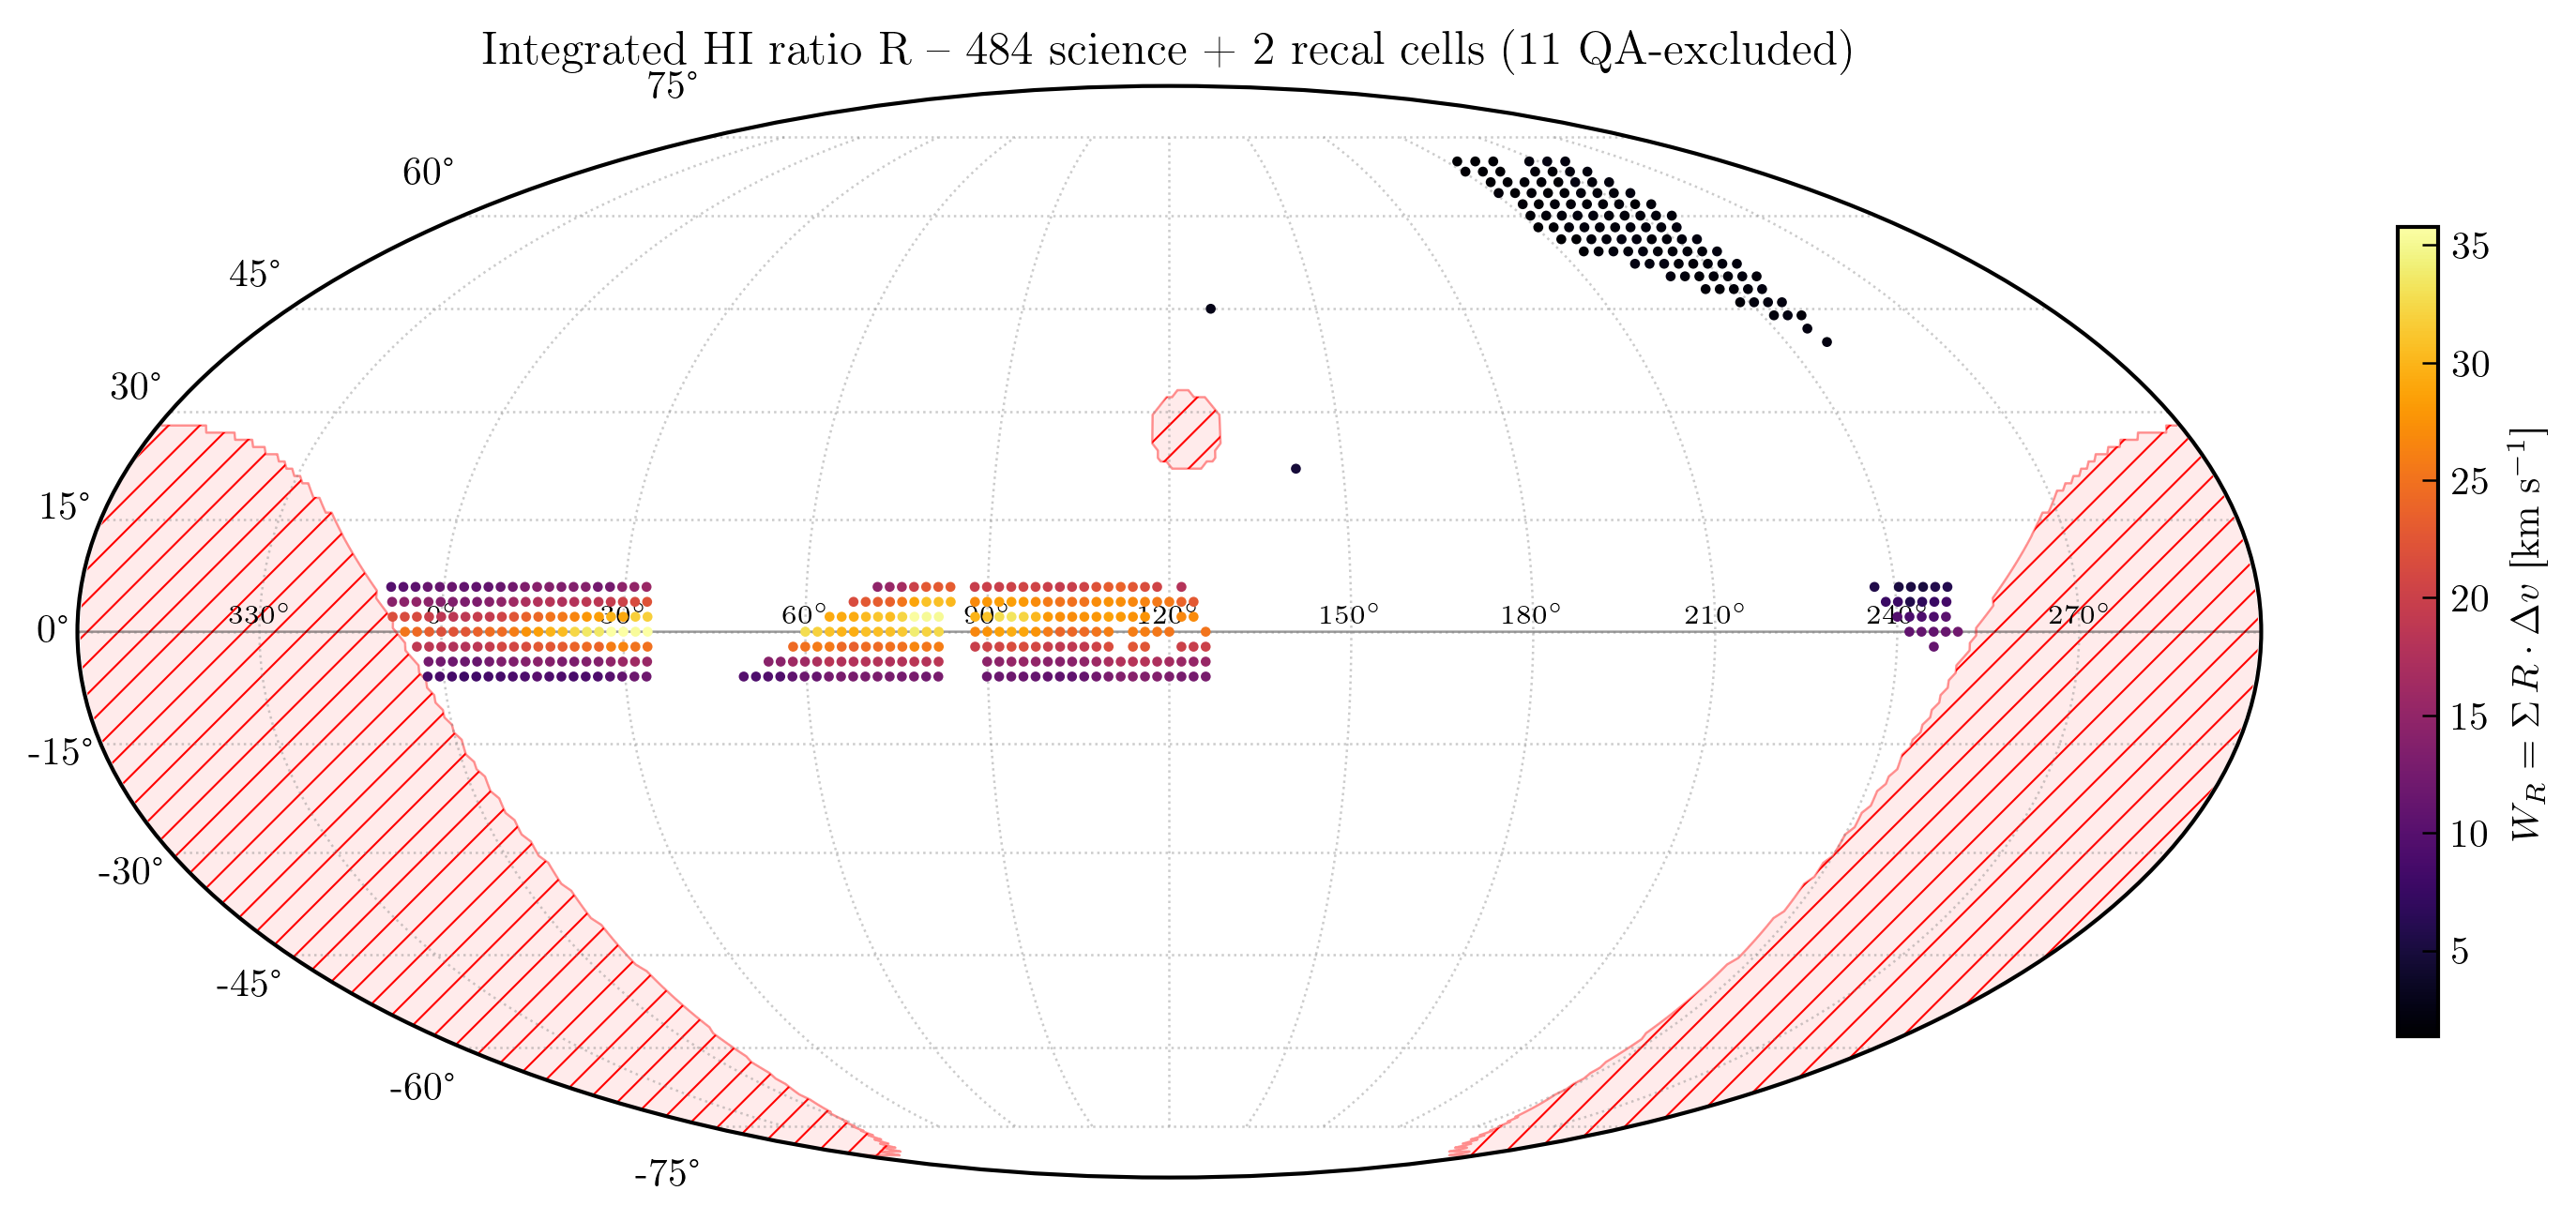

In [10]:
arrs = assemble_W_R_arrays(cell_combined, recal_cells, qa_flagged_set, dv_kms)
gl_arr, gb_arr, W_R, valid_R = arrs['gl'], arrs['gb'], arrs['W_R'], arrs['valid']

fig, ax = plot_survey_mollweide(
    gl_arr[valid_R], gb_arr[valid_R], W_R[valid_R],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W_R = \Sigma\, R \cdot \Delta v$ [km s$^{-1}$]',
    cmap='inferno',
    marker_size=(SS_FINE + SS_MICRO) / 2,
    title=(f'Integrated HI ratio R -- {arrs["n_sci"]} science + '
           f'{arrs["n_recal"]} recal cells '
           f'({len(qa_flagged_set)} QA-excluded)'),
)
plt.show()

## 7. Beam-weighted Mollweide map of integrated R

Beam-weighted resampling of `W_R(l, b)` onto a fine pixel grid (both
science and recal cells included). Each pixel is a Gaussian-beam-weighted
average over pointings whose 3.4 deg HPBW partially overlaps it (cutoff
at 2 * HPBW). Pixels with negligible total weight are masked.

Units are km/s -- no temperature calibration applied.


/home/ikaros/projects/ay-121/labs/04/plotters.py:557: RuntimeWarning: invalid value encountered in divide
  img = np.where(den > min_weight, num / den, np.nan).reshape(LL.shape)


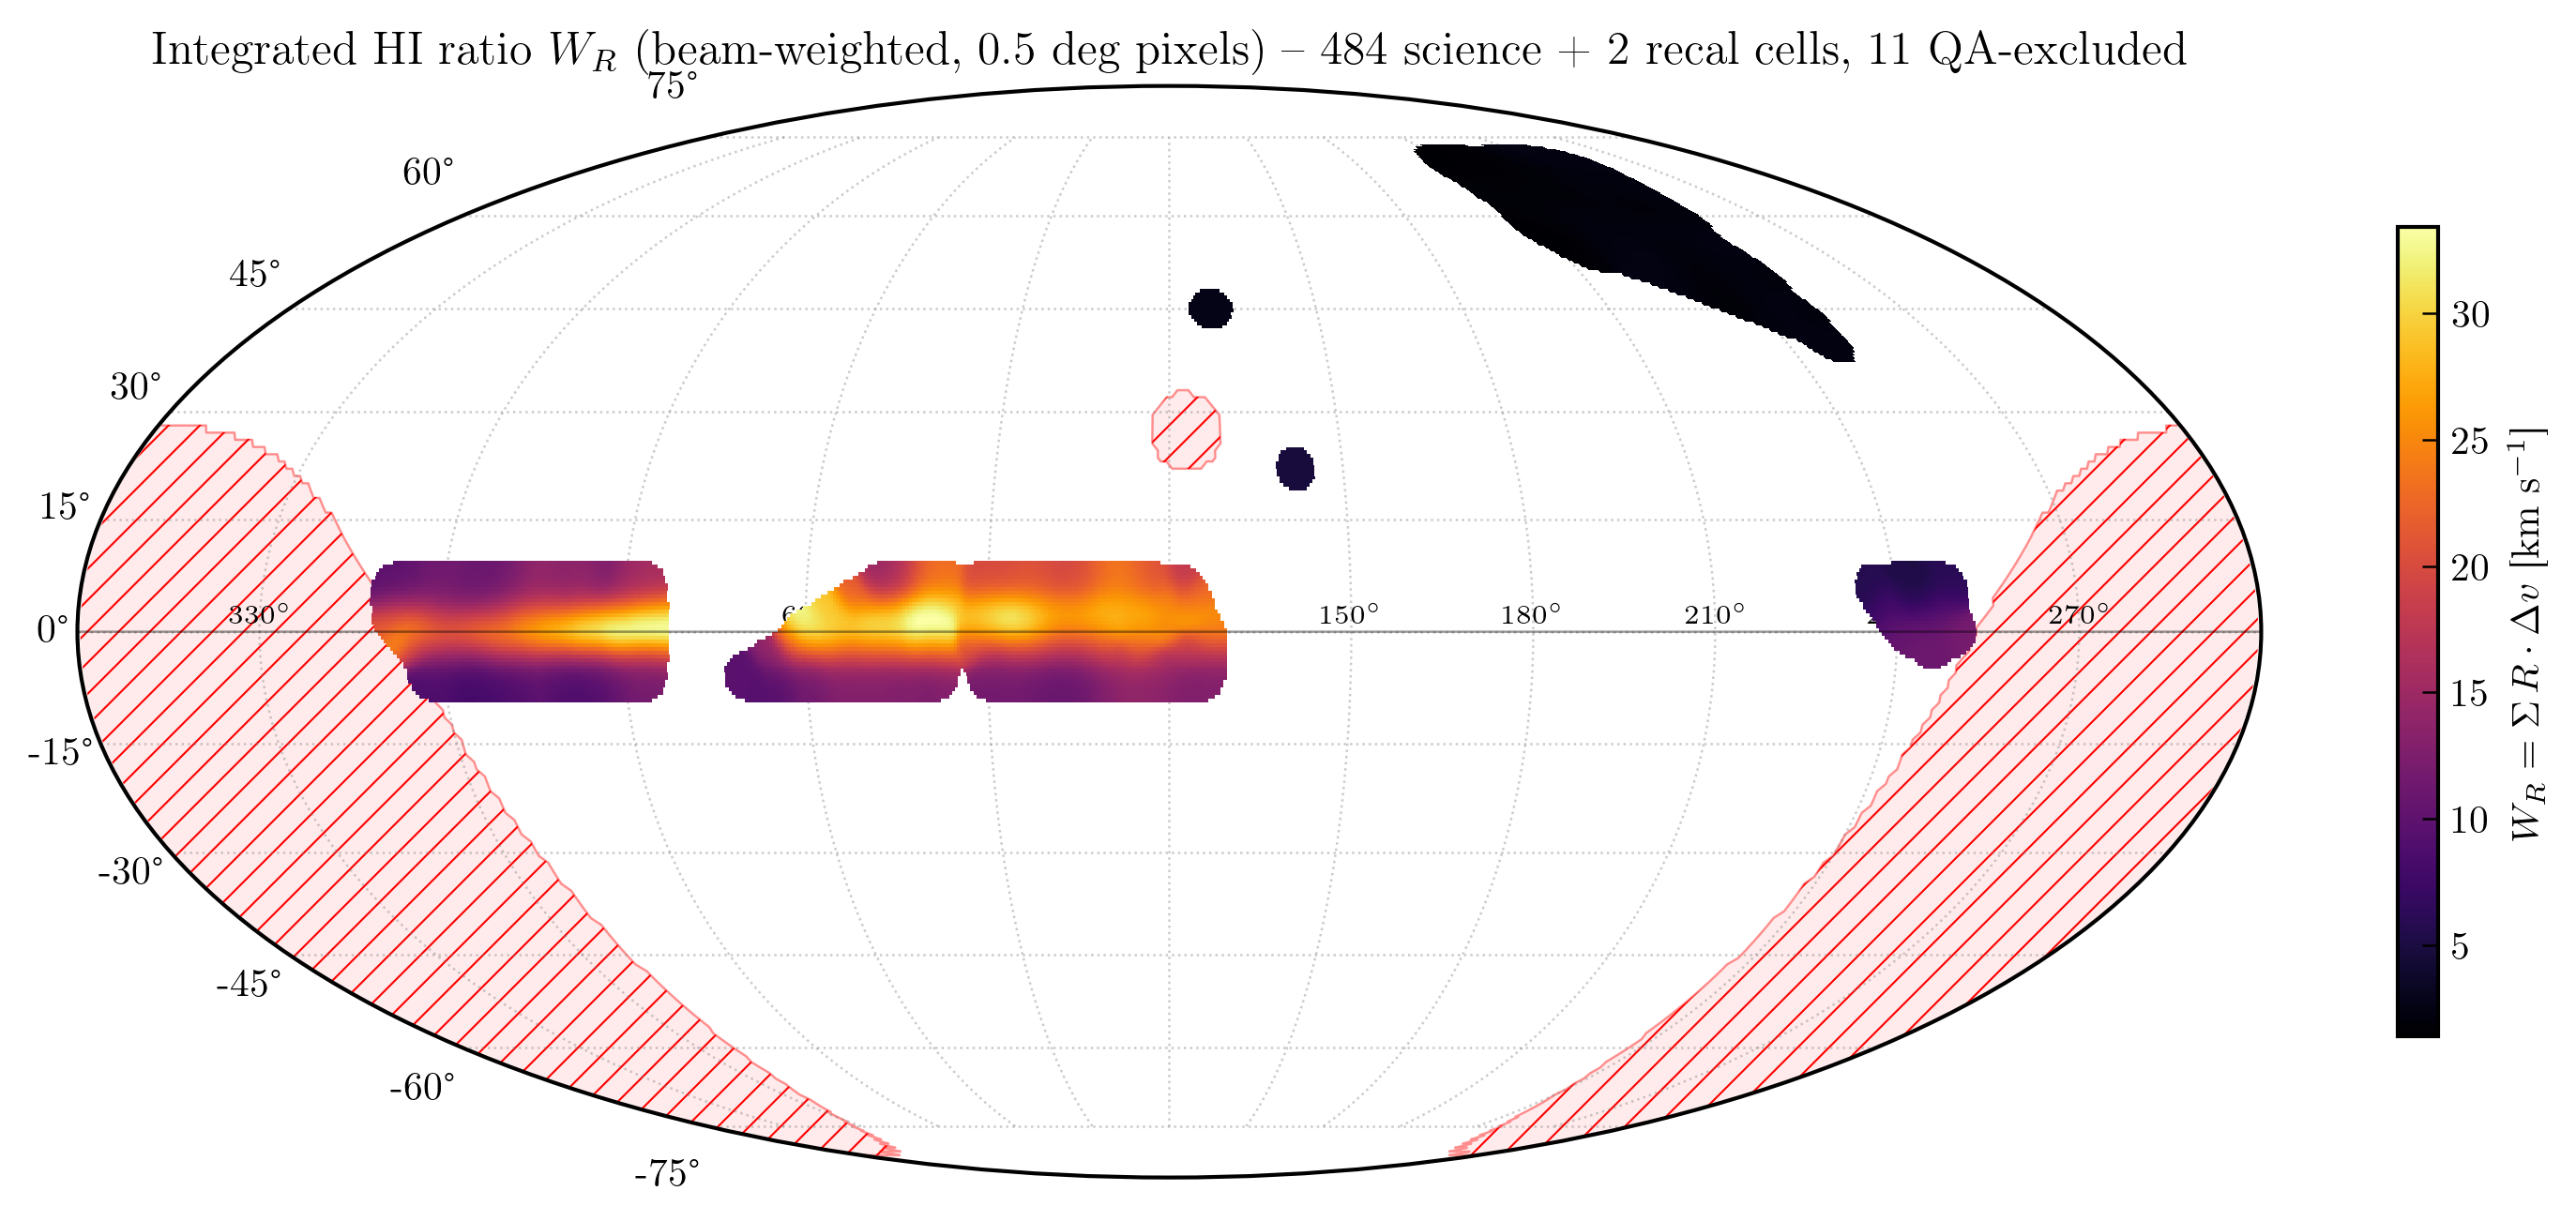

In [11]:
PIXEL_DEG = 0.5      # Mollweide pixel size (deg); finer than HPBW for smooth fill
CUTOFF_HPBW = 2.0    # include pointings within this many HPBW of each pixel center

fig, ax = plot_survey_mollweide_gridded(
    gl_arr[valid_R], gb_arr[valid_R], W_R[valid_R],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W_R = \Sigma\, R \cdot \Delta v$ [km s$^{-1}$]',
    cmap='inferno',
    hpbw_deg=HPBW_DEG,
    pixel_deg=PIXEL_DEG,
    cutoff_hpbw=CUTOFF_HPBW,
    title=(f'Integrated HI ratio $W_R$ (beam-weighted, {PIXEL_DEG} deg pixels) -- '
           f'{arrs["n_sci"]} science + {arrs["n_recal"]} recal cells, '
           f'{len(qa_flagged_set)} QA-excluded'),
)
plt.show()

In [12]:
# Export state for scan_load_lv.ipynb / scan_load_diagnostics.ipynb.
# No T-calibration: spectra in cell_combined are the dimensionless ratio R(v_LSR).
# Recal visits and aggregated recal cells (both pols) are exported alongside.
import pickle

state = {
    'cell_combined': cell_combined,
    'qa_flagged_set': qa_flagged_set,
    'v_lsr_overlap': v_lsr_overlap,
    'dv_kms': dv_kms,
    'overlap_mask': overlap_mask,
    'sessions': sessions,
    'recal_visits': recal_visits,
    'recal_cells': recal_cells,
}
with open(STATE_PATH, 'wb') as f:
    pickle.dump(state, f)
print(f'Wrote {STATE_PATH} ({STATE_PATH.stat().st_size/1e6:.2f} MB) -- '
      f'{len(cell_combined)} science cells, {len(qa_flagged_set)} QA-flagged, '
      f'{len(recal_cells)} recal cells ({sum(len(v) for v in recal_visits.values())} visits)')


Wrote artifacts/scan_load_state.pkl (2.54 MB) -- 495 science cells, 11 QA-flagged, 2 recal cells (63 visits)
